In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def generate_mandelbrot_naive(width, height, max_iter):
    # Define region: x in [-2, 1], y in [-1.5, 1.5]
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5
    
    # Create grid of complex numbers c over this region
    # Generate width evenly spaced x-values and height evenly spaced y-values
    x_vals = np.linspace(xmin, xmax, width)
    y_vals = np.linspace(ymin, ymax, height)
    
    # Return 2D array of iteration counts
    # Initialize the array to hold our results
    iterations = np.zeros((height, width))
    
    # For each point c in grid
    for i, y in enumerate(y_vals):
        for j, x in enumerate(x_vals):
            # Form complex numbers: c = x + iy for each grid point 
            c = complex(x, y)
            
            # Initialize z_0 = 0
            z = 0.0 + 0.0j
            
            # For n = 0 to max_iter:
            for n in range(max_iter):
                # Compute z_{n+1} = z_n^2 + c
                z = z**2 + c
                
                # If |z_{n+1}| > 2 Point escapes
                # Threshold |z| > 2 guarantees divergence
                if abs(z) > 2.0:
                    iterations[i, j] = n # Store n
                    break
            else:
                # If loop completes: Point is in set, store max_iter
                iterations[i, j] = max_iter
                
    return iterations

In [4]:
# Typical: max_iter = 100, resolution: 1024x1024 
width, height = 1024, 1024
max_iter = 100

In [6]:
print("Calculating Mandelbrot set (Naive)....")
mandelbrot_image = generate_mandelbrot_naive(width, height, max_iter)

Calculating Mandelbrot set (Naive)....


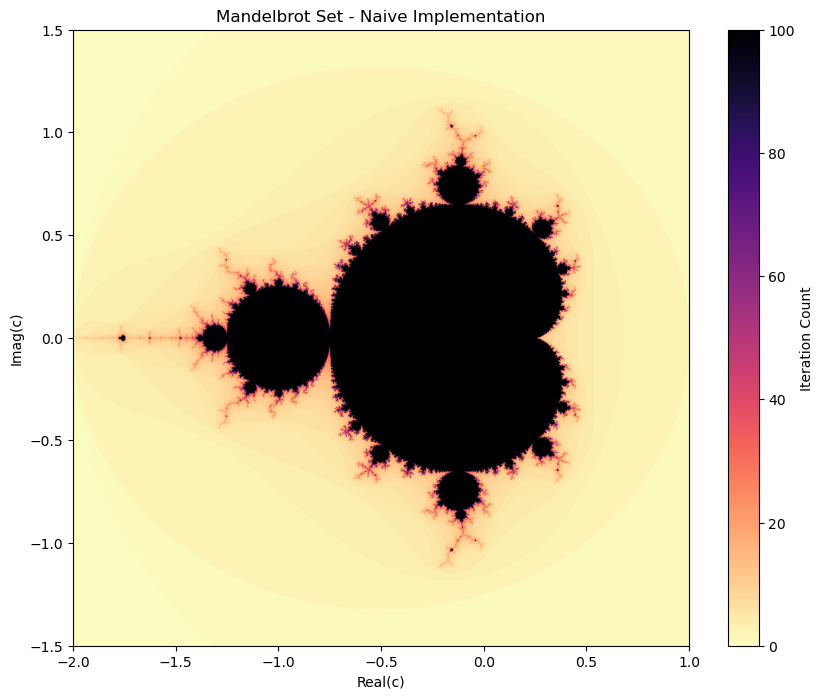

In [7]:
# Visualize with colormap
plt.figure(figsize=(10, 8))
# Using 'magma' gives a great visual representation
plt.imshow(mandelbrot_image, cmap='magma_r', extent=[-2.0, 1.0, -1.5, 1.5]) 
plt.colorbar(label='Iteration Count')
plt.title("Mandelbrot Set - Naive Implementation")
plt.xlabel("Real(c)")
plt.ylabel("Imag(c)")
plt.show()

Highest number, gets the maximum brightness here. the black part in center represents that the points were inside the unit 2, modulus. 

## NumPy Vectorized Implementation


In [5]:
def generate_mandelbrot_numpy(width, height, max_iter):
    # Define region: x in [-2, 1] and y in [-1.5, 1.5]
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5

    # Build the full complex grid in one shot
    x_vals = np.linspace(xmin, xmax, width)
    y_vals = np.linspace(ymin, ymax, height)
    X, Y = np.meshgrid(x_vals, y_vals)
    C = X + 1j * Y                        # complex c for every pixel

    Z = np.zeros_like(C)                             # z_0 = 0 for all points
    iterations = np.full((height, width), max_iter)  # defaultt
    not_escaped = np.ones((height, width), dtype=bool)

    for n in range(max_iter):
        # Apply to points that haven't escaped yet
        Z[not_escaped] = Z[not_escaped] ** 2 + C[not_escaped]

        # Detect newly escaped points (|z| > 2)
        newly_escaped = not_escaped & (np.abs(Z) > 2.0)
        iterations[newly_escaped] = n   # record escape iteration

        # Remove newly escaped points
        not_escaped[newly_escaped] = False

        # Early exit
        if not not_escaped.any():
            break

    return iterations


In [9]:
print("Calculating Mandelbrot set (NumPy vectorized)....")
mandelbrot_numpy = generate_mandelbrot_numpy(width, height, max_iter)


Calculating Mandelbrot set (NumPy vectorized)....


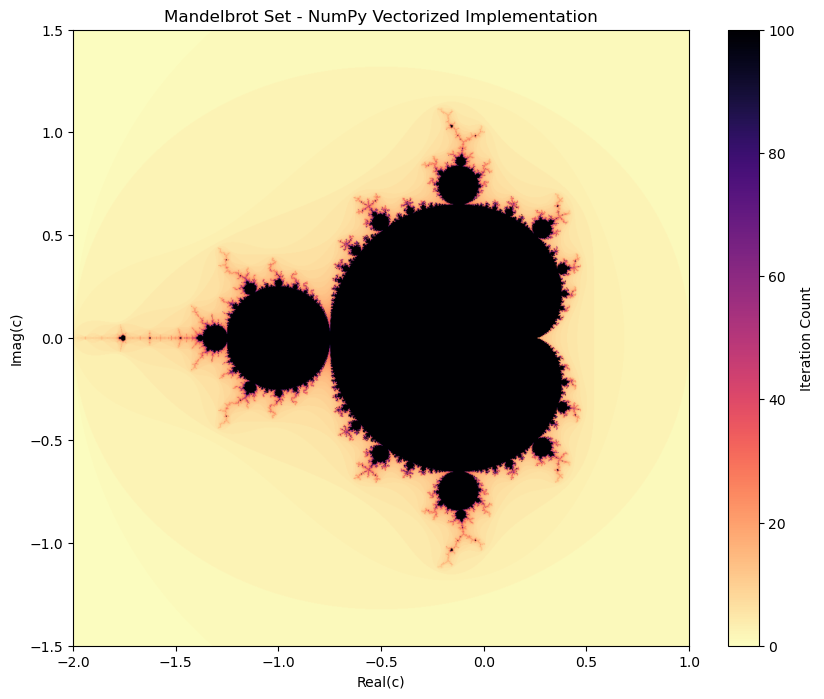

In [10]:
# Visualize the NumPy vectorized result
plt.figure(figsize=(10, 8))
plt.imshow(mandelbrot_numpy, cmap='magma_r', extent=[-2.0, 1.0, -1.5, 1.5])
plt.colorbar(label='Iteration Count')
plt.title("Mandelbrot Set - NumPy Vectorized Implementation")
plt.xlabel("Real(c)")
plt.ylabel("Imag(c)")
plt.show()


## Numba JIT-Compiled Implementation



In [6]:
from numba import njit


In [7]:
@njit
def generate_mandelbrot_numba(width, height, max_iter):
    # Define region: x in [-2, 1], y in [-1.5, 1.5]
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5

    iterations = np.zeros((height, width))

    for i in range(height):
        for j in range(width):
            # Map pixel indices to complex plane coordinates
            x = xmin + j * (xmax - xmin) / (width - 1)
            y = ymin + i * (ymax - ymin) / (height - 1)
            c = complex(x, y)

            z = 0.0 + 0.0j
            for n in range(max_iter):
                z = z * z + c          # slightly faster than z**2
                if z.real * z.real + z.imag * z.imag > 4.0:  # |z|^2 > 4 avoids sqrt
                    iterations[i, j] = n
                    break
            else:
                iterations[i, j] = max_iter

    return iterations

_ = generate_mandelbrot_numba(8, 8, 10)
print("Numba JIT compiled and ready.")


Numba JIT compiled and ready.


In [13]:
print("Calculating Mandelbrot set (Numba JIT)....")
mandelbrot_numba = generate_mandelbrot_numba(width, height, max_iter)
print("Done.")


Calculating Mandelbrot set (Numba JIT)....
Done.


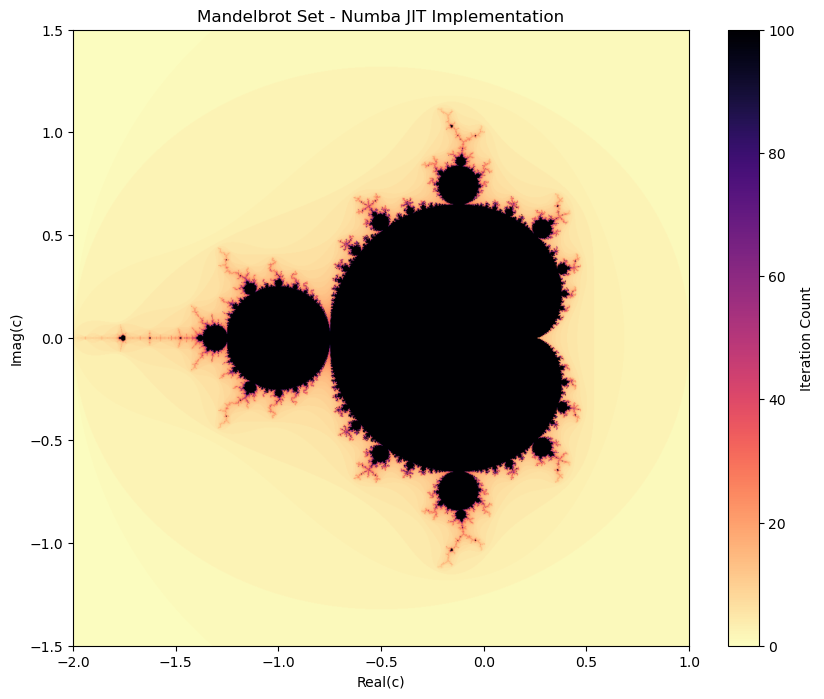

In [14]:
# Visualize the Numba JIT result
plt.figure(figsize=(10, 8))
plt.imshow(mandelbrot_numba, cmap='magma_r', extent=[-2.0, 1.0, -1.5, 1.5])
plt.colorbar(label='Iteration Count')
plt.title("Mandelbrot Set - Numba JIT Implementation")
plt.xlabel("Real(c)")
plt.ylabel("Imag(c)")
plt.show()


## Performance Analysis

Let's measure the execution time of all three implementations using consistent parameters and calculate speedups.

In [8]:
import time

# Use consistent parameters for all three versions
width_perf, height_perf = 1024, 1024
max_iter_perf = 100
num_runs = 3  # Run each version multiple times for stable measurements

print("=" * 70)
print("PERFORMANCE ANALYSIS: Mandelbrot Set Implementations")
print("=" * 70)
print(f"Parameters: {width_perf}x{height_perf} resolution, {max_iter_perf} max iterations")
print(f"Each measurement averaged over {num_runs} runs\n")

# ============================================================================
# NAIVE IMPLEMENTATION TIMING
# ============================================================================
print("1. NAIVE (Pure Python with nested loops)")
print("-" * 70)
naive_times = []
for run in range(num_runs):
    start = time.perf_counter()
    _ = generate_mandelbrot_naive(width_perf, height_perf, max_iter_perf)
    end = time.perf_counter()
    elapsed = end - start
    naive_times.append(elapsed)
    print(f"   Run {run + 1}: {elapsed:.4f} seconds")

naive_avg = sum(naive_times) / len(naive_times)
print(f"   Average: {naive_avg:.4f} seconds\n")

# ============================================================================
# NUMPY VECTORIZED IMPLEMENTATION TIMING
# ============================================================================
print("2. NUMPY VECTORIZED (NumPy operations)")
print("-" * 70)
numpy_times = []
for run in range(num_runs):
    start = time.perf_counter()
    _ = generate_mandelbrot_numpy(width_perf, height_perf, max_iter_perf)
    end = time.perf_counter()
    elapsed = end - start
    numpy_times.append(elapsed)
    print(f"   Run {run + 1}: {elapsed:.4f} seconds")

numpy_avg = sum(numpy_times) / len(numpy_times)
print(f"   Average: {numpy_avg:.4f} seconds\n")

# ============================================================================
# NUMBA JIT-COMPILED IMPLEMENTATION TIMING
# ============================================================================
print("3. NUMBA JIT (JIT-compiled to machine code)")
print("-" * 70)
numba_times = []
for run in range(num_runs):
    start = time.perf_counter()
    _ = generate_mandelbrot_numba(width_perf, height_perf, max_iter_perf)
    end = time.perf_counter()
    elapsed = end - start
    numba_times.append(elapsed)
    print(f"   Run {run + 1}: {elapsed:.4f} seconds")

numba_avg = sum(numba_times) / len(numba_times)
print(f"   Average: {numba_avg:.4f} seconds\n")

PERFORMANCE ANALYSIS: Mandelbrot Set Implementations
Parameters: 1024x1024 resolution, 100 max iterations
Each measurement averaged over 3 runs

1. NAIVE (Pure Python with nested loops)
----------------------------------------------------------------------
   Run 1: 6.3629 seconds
   Run 2: 6.2823 seconds
   Run 3: 5.9449 seconds
   Average: 6.1967 seconds

2. NUMPY VECTORIZED (NumPy operations)
----------------------------------------------------------------------
   Run 1: 2.3928 seconds
   Run 2: 2.4489 seconds
   Run 3: 2.1965 seconds
   Average: 2.3460 seconds

3. NUMBA JIT (JIT-compiled to machine code)
----------------------------------------------------------------------
   Run 1: 0.0946 seconds
   Run 2: 0.0953 seconds
   Run 3: 0.0945 seconds
   Average: 0.0948 seconds



In [9]:
# ============================================================================
# SPEEDUP CALCULATIONS
# ============================================================================
print("=" * 70)
print("SPEEDUP ANALYSIS (relative to Naive implementation)")
print("=" * 70)

numpy_speedup = naive_avg / numpy_avg
numba_speedup = naive_avg / numba_avg

print(f"NumPy vs Naive:  {numpy_speedup:.2f}x faster")
print(f"Numba vs Naive:  {numba_speedup:.2f}x faster")
print(f"Numba vs NumPy:  {numba_speedup / numpy_speedup:.2f}x faster\n")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Implementation':<20} {'Avg Time (s)':<15} {'Speedup':<15}")
print("-" * 70)
print(f"{'Naive':<20} {naive_avg:<15.4f} {'1.00x (baseline)':<15}")
print(f"{'NumPy':<20} {numpy_avg:<15.4f} {f'{numpy_speedup:.2f}x':<15}")
print(f"{'Numba':<20} {numba_avg:<15.4f} {f'{numba_speedup:.2f}x':<15}")
print("=" * 70)

SPEEDUP ANALYSIS (relative to Naive implementation)
NumPy vs Naive:  2.64x faster
Numba vs Naive:  65.37x faster
Numba vs NumPy:  24.75x faster

SUMMARY TABLE
Implementation       Avg Time (s)    Speedup        
----------------------------------------------------------------------
Naive                6.1967          1.00x (baseline)
NumPy                2.3460          2.64x          
Numba                0.0948          65.37x         


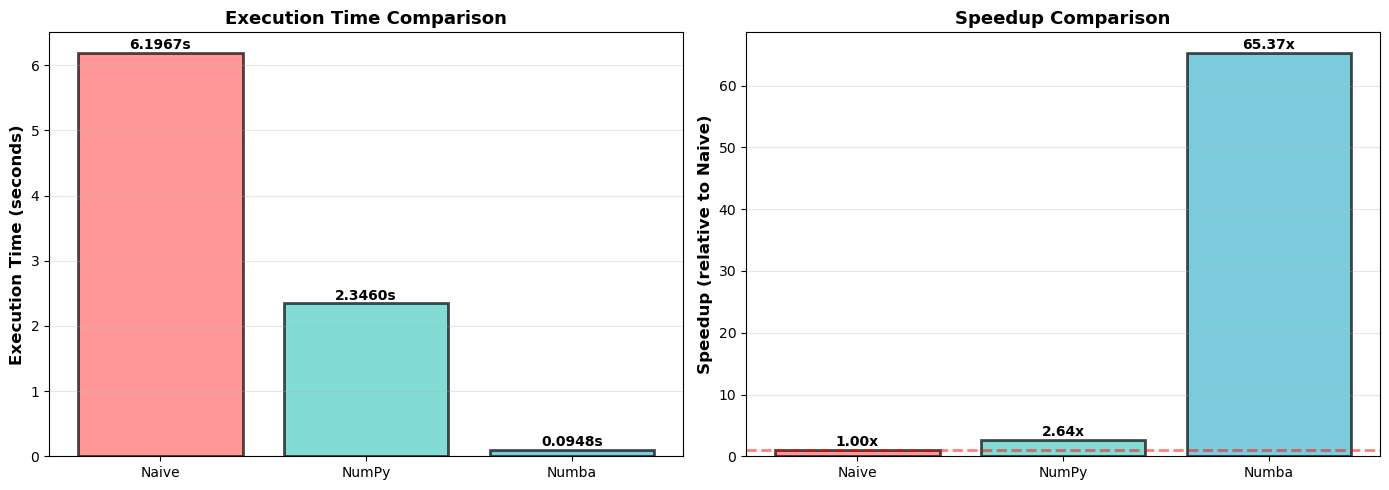

In [10]:
# Visualization of execution times
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Execution Times
implementations = ['Naive', 'NumPy', 'Numba']
times = [naive_avg, numpy_avg, numba_avg]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax1.bar(implementations, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Execution Time Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (impl, time_val) in enumerate(zip(implementations, times)):
    ax1.text(i, time_val + 0.01, f'{time_val:.4f}s', ha='center', va='bottom', fontweight='bold')

# Bar chart: Speedups
speedups = [1.0, numpy_speedup, numba_speedup]
ax2.bar(implementations, speedups, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Speedup (relative to Naive)', fontsize=12, fontweight='bold')
ax2.set_title('Speedup Comparison', fontsize=13, fontweight='bold')
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
ax2.grid(axis='y', alpha=0.3)
for i, (impl, speedup_val) in enumerate(zip(implementations, speedups)):
    ax2.text(i, speedup_val + 0.1, f'{speedup_val:.2f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()